In [4]:
import os, pickle, torch, torch.nn as nn, torch.optim as optim
import re, pandas as pd, nltk, numpy as np, random, matplotlib.pyplot as plt
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
from tqdm import tqdm
from collections import Counter
from nltk.tokenize import word_tokenize
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device {device}")

Using device cpu


# Part 1: Image Processing & Feature extraction


In [ ]:
def find_image_dir():
    
    candidate_roots = ['/kaggle/input', './data', '../data']
    for base_input in candidate_roots:
        if not os.path.isdir(base_input):
            continue
        # Walk through the directory to find where the images actually are
        for root, dirs, files in os.walk(base_input):
            # Look for the folder containing a high volume of jpg files
            if len([f for f in files if f.endswith('.jpg')]) > 1000:
                return root
    return None

IMAGE_DIR = find_image_dir()
OUTPUT_FILE = 'flickr30k_features_spatial.pkl'

if IMAGE_DIR:
    print(f" Found images at: {IMAGE_DIR}")
else:
    raise FileNotFoundError("Could not find the Flickr30k image directory. Please ensure the dataset is added to the notebook (Kaggle) or downloaded to ./data locally.")


# --- THE DATASET CLASS ---
class ImageFolderDataset(Dataset):
    def __init__(self, img_dir, transform):
        self.img_names = [f for f in os.listdir(img_dir) if f.endswith(('.jpg', '.jpeg'))]
        self.transform = transform
        self.img_dir = img_dir

    def __len__(self):
        return len(self.img_names)
    def __getitem__(self, idx):
        name = self.img_names[idx]
        img_path = os.path.join(self.img_dir, name)
        img = Image.open(img_path).convert('RGB')
        return self.transform(img), name


# SPATIAL FEATURE EXTRACTOR (drop avgpool + fc, keep the 7x7 grid) 
NUM_PIXELS = 49
SPATIAL_FEATURE_SIZE = 2048

cnn = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
cnn = nn.Sequential(*list(cnn.children())[:-2])  # (batch, 2048, 7, 7)
if torch.cuda.device_count() > 1:
    cnn = nn.DataParallel(cnn)  
cnn = cnn.to(device)
cnn.eval()

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

dataset = ImageFolderDataset(IMAGE_DIR, transform)
loader = DataLoader(dataset, batch_size=128, num_workers=0)
features_dict = {}

with torch.no_grad():
    for imgs, names in tqdm(loader, desc="Extracting Spatial Features"):
        feats = cnn(imgs.to(device))  # (batch, 2048, 7, 7) each
        feats = feats.permute(0, 2, 3, 1).reshape(feats.size(0), -1, SPATIAL_FEATURE_SIZE)  # (batch, 49, 2048)
        feats = feats.half().cpu().numpy()  # float16 to save disk space
        for i, name in enumerate(names):
            features_dict[name] = feats[i]

with open(OUTPUT_FILE, 'wb') as f:
    pickle.dump(features_dict, f)

print(f"Success! {len(features_dict)} images processed and saved to {OUTPUT_FILE}")


 Found images at: ./data/Images


# Part 2: Vocabulary & Text Pre-Processing


In [6]:
nltk.download('punkt')

# --- LOAD DATA ---
candidate_caption_files = ['/kaggle/input/flickr30k/captions.txt', './data/captions.txt', '../data/captions.txt']
captions_file = next((p for p in candidate_caption_files if os.path.isfile(p)), None)
if captions_file is None:
    raise FileNotFoundError("Could not find captions.txt. Checked: " + ', '.join(candidate_caption_files))
dataframe = pd.read_csv(captions_file, sep=',')

print(f"Loaded {len(dataframe)} captions from {captions_file}")

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/kelvinnguyen/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Loaded 158915 captions from ./data/captions.txt


In [7]:
# --- CLEAN CAPTIONS ---
def clean_caption(caption):
    caption = str(caption).lower()
    caption = re.sub(r'[^a-z\s]', '', caption)
    caption = ' '.join(caption.split())
    return caption

dataframe['caption'] = dataframe['caption'].apply(clean_caption)
dataframe['tokens'] = dataframe['caption'].apply(lambda x: x.split())
dataframe['tokens'] = dataframe['tokens'].apply(lambda x: ['<start>'] + x + ['<end>'])
print("Example tokenized caption:")
print(dataframe['tokens'].iloc[0])

Example tokenized caption:
['<start>', 'two', 'young', 'guys', 'with', 'shaggy', 'hair', 'look', 'at', 'their', 'hands', 'while', 'hanging', 'out', 'in', 'the', 'yard', '<end>']


In [ ]:
# --- BUILD VOCAB ---
# Collect all tokens from all captions
all_tokens = []
for token_list in dataframe['tokens']:
    all_tokens.extend(token_list)

token_counts = Counter(all_tokens)

# Filter by minimum frequency, words occurring less than 5 times are removed
MIN_FREQ = 5
vocab = [token for token, count in token_counts.items() if count >= MIN_FREQ]
special_tokens = ['<pad>', '<start>', '<end>', '<unk>']
vocab = special_tokens + [v for v in vocab if v not in special_tokens]
word2idx = {word: idx for idx, word in enumerate(vocab)}
idx2word = {idx: word for idx, word in enumerate(vocab)}

print(f"\nVocabulary size: {len(vocab)}")
print(f"Most common tokens: {token_counts.most_common(20)}")


Vocabulary size: 7689
Most common tokens: [('a', 271705), ('<start>', 158915), ('<end>', 158915), ('in', 83466), ('the', 62978), ('on', 45669), ('and', 44263), ('man', 42598), ('is', 41117), ('of', 38776), ('with', 36207), ('woman', 22211), ('two', 21642), ('are', 20196), ('to', 17607), ('people', 17337), ('at', 16259), ('an', 15883), ('wearing', 15709), ('young', 13218)]


In [9]:
# --- CONVERT TOKENS TO INDICES ---
def tokens_to_indices(tokens, word2idx):
    indices = []
    for token in tokens:
        if token in word2idx:
            indices.append(word2idx[token])
        else:
            indices.append(word2idx['<unk>'])
    return indices

dataframe['indices'] = dataframe['tokens'].apply(lambda x: tokens_to_indices(x, word2idx))

In [10]:
# --- CHOOSE MAX LENGTH ---
# Get length of each caption (in tokens)
caption_lengths = dataframe['tokens'].apply(len)

MAX_LENGTH = int(np.percentile(caption_lengths, 95))
print(f"\nUsing MAX_LENGTH: {MAX_LENGTH}")

# Check how many captions will be truncated
num_truncated = (caption_lengths > MAX_LENGTH).sum()
print(f"Captions to be truncated: {num_truncated} ({num_truncated/len(dataframe)*100:.2f}%)")


Using MAX_LENGTH: 24
Captions to be truncated: 6779 (4.27%)


In [ ]:

def pad_or_truncate(indices, max_length, pad_idx):
    if len(indices) > max_length:
        # Truncate (but keep <end> token)
        return indices[:max_length-1] + [indices[-1]]  # Keep <end>
    else:
        # Pad with <pad> tokens
        return indices + [pad_idx] * (max_length - len(indices))

# Apply padding/truncation
PAD_IDX = word2idx['<pad>']
dataframe['padded_indices'] = dataframe['indices'].apply(
    lambda x: pad_or_truncate(x, MAX_LENGTH, PAD_IDX)
)

# Verify all have same length
assert all(len(x) == MAX_LENGTH for x in dataframe['padded_indices']), "Not all sequences have MAX_LENGTH!"
print(f"\nAll captions now have length {MAX_LENGTH}")


All captions now have length 24


In [ ]:
#  update image to captions mapping
image_to_captions = {}
for idx, row in dataframe.iterrows():
    img_name = row['image']
    caption_indices = row['padded_indices']

    if img_name not in image_to_captions:
        image_to_captions[img_name] = []

    image_to_captions[img_name].append(caption_indices)

# save with max length
with open('vocab.pkl', 'wb') as frame:
    pickle.dump({
        'word2idx': word2idx,
        'idx2word': idx2word,
        'vocab': vocab,
        'max_length': MAX_LENGTH,
        'pad_idx': PAD_IDX
    }, frame)

with open('image_to_captions.pkl', 'wb') as frame:
    pickle.dump(image_to_captions, frame)

print("\n --- Preprocessing complete --- ")
print(f"Vocabulary size: {len(vocab)}")
print(f"Max caption length: {MAX_LENGTH}")
print(f"Total images: {len(image_to_captions)}")



 --- Preprocessing complete --- 
Vocabulary size: 7689
Max caption length: 24
Total images: 31783


# Part 3: Attention-Based Seq2Seq Architecture

In [13]:
# Load vocabulary + spatial image features
with open('vocab.pkl', 'rb') as f:
    vocab_data = pickle.load(f)
    word2idx = vocab_data['word2idx']
    idx2word = vocab_data['idx2word']
    vocab = vocab_data['vocab']
    MAX_LENGTH = vocab_data['max_length']
    PAD_IDX = vocab_data['pad_idx']

with open('flickr30k_features_spatial.pkl', 'rb') as f:
    image_features = pickle.load(f)

with open('image_to_captions.pkl', 'rb') as f:
    image_to_captions = pickle.load(f)

In [14]:
VOCAB_SIZE = len(vocab)
EMBED_SIZE = 256
ENCODER_DIM = 512      # projected spatial-feature dimension (replaces the old single HIDDEN_SIZE encoder output)
DECODER_DIM = 512      # LSTM hidden size
ATTENTION_DIM = 256    # size of the attention scoring layer
FEATURE_SIZE = 2048    # raw ResNet50 channel depth per spatial location

BATCH_SIZE = 64
LEARNING_RATE = 0.001
NUM_EPOCHS = 30

print(f"Vocab Size: {VOCAB_SIZE}")
print(f"Embedding Size: {EMBED_SIZE}")
print(f"Encoder Dim: {ENCODER_DIM}")
print(f"Decoder Dim: {DECODER_DIM}")
print(f"Attention Dim: {ATTENTION_DIM}")

Vocab Size: 7689
Embedding Size: 256
Encoder Dim: 512
Decoder Dim: 512
Attention Dim: 256


In [15]:
class Encoder(nn.Module):
    """Projects each of the 49 spatial ResNet50 feature vectors (2048-d) down to ENCODER_DIM,
    instead of pooling them into a single vector."""
    def __init__(self, feature_size=2048, encoder_dim=512, dropout=0.5):
        super(Encoder, self).__init__()
        self.fc = nn.Linear(feature_size, encoder_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

    def forward(self, features):
        # features: (batch, num_pixels, feature_size) -> (batch, num_pixels, encoder_dim)
        out = self.fc(features)
        out = self.relu(out)
        out = self.dropout(out)
        return out

encoder = Encoder(FEATURE_SIZE, ENCODER_DIM).to(device)
print("Encoder (spatial projection) initialized")
print(encoder)

Encoder (spatial projection) initialized
Encoder(
  (fc): Linear(in_features=2048, out_features=512, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
)


In [16]:
class Attention(nn.Module):
    """Bahdanau-style additive attention over the encoder's spatial feature grid."""
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super(Attention, self).__init__()
        self.encoder_att = nn.Linear(encoder_dim, attention_dim)
        self.decoder_att = nn.Linear(decoder_dim, attention_dim)
        self.full_att = nn.Linear(attention_dim, 1)
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)

    def forward(self, encoder_out, decoder_hidden):
        # encoder_out: (batch, num_pixels, encoder_dim)
        # decoder_hidden: (batch, decoder_dim)
        att1 = self.encoder_att(encoder_out)                          # (batch, num_pixels, attention_dim)
        att2 = self.decoder_att(decoder_hidden).unsqueeze(1)          # (batch, 1, attention_dim)
        att = self.full_att(self.relu(att1 + att2)).squeeze(2)        # (batch, num_pixels)
        alpha = self.softmax(att)                                     # (batch, num_pixels)
        context = (encoder_out * alpha.unsqueeze(2)).sum(dim=1)       # (batch, encoder_dim)
        return context, alpha

print("Attention module defined")

Attention module defined


In [ ]:
class DecoderWithAttention(nn.Module):
    def __init__(self, vocab_size, embed_size, encoder_dim, decoder_dim, attention_dim, pad_idx=0, dropout=0.5):
        super(DecoderWithAttention, self).__init__()
        self.vocab_size = vocab_size
        self.decoder_dim = decoder_dim

        self.attention = Attention(encoder_dim, decoder_dim, attention_dim)
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=pad_idx)
        self.dropout = nn.Dropout(dropout)
        self.lstm_cell = nn.LSTMCell(embed_size + encoder_dim, decoder_dim, bias=True)

        # initial hidden/cell state from the mean of the spatial features
        self.init_h = nn.Linear(encoder_dim, decoder_dim)
        self.init_c = nn.Linear(encoder_dim, decoder_dim)

        # gating scalar on the attention context 
        self.f_beta = nn.Linear(decoder_dim, encoder_dim)
        self.sigmoid = nn.Sigmoid()

        self.fc = nn.Linear(decoder_dim, vocab_size)

    def init_hidden_state(self, encoder_out):
        mean_encoder_out = encoder_out.mean(dim=1)
        h = self.init_h(mean_encoder_out)
        c = self.init_c(mean_encoder_out)
        return h, c

    def forward_step(self, encoder_out, h, c, word_idx):
        """One decoding step. word_idx: (batch,) token indices of the current input word."""
        embedding = self.embedding(word_idx)               # (batch, embed_size)
        context, alpha = self.attention(encoder_out, h)    # (batch, encoder_dim), (batch, num_pixels)
        gate = self.sigmoid(self.f_beta(h))
        gated_context = gate * context
        lstm_input = torch.cat([embedding, gated_context], dim=1)
        h, c = self.lstm_cell(lstm_input, (h, c))
        preds = self.fc(self.dropout(h))
        return preds, h, c, alpha

    def forward(self, encoder_out, captions):
        """Teacher-forced forward pass over a full caption sequence.
        encoder_out: (batch, num_pixels, encoder_dim)
        captions: (batch, seq_len) token indices (the decoder's input sequence)
        """
        batch_size = encoder_out.size(0)
        seq_len = captions.size(1)
        h, c = self.init_hidden_state(encoder_out)
        outputs = torch.zeros(batch_size, seq_len, self.vocab_size, device=encoder_out.device)
        for t in range(seq_len):
            preds, h, c, _ = self.forward_step(encoder_out, h, c, captions[:, t])
            outputs[:, t, :] = preds
        return outputs

decoder = DecoderWithAttention(VOCAB_SIZE, EMBED_SIZE, ENCODER_DIM, DECODER_DIM, ATTENTION_DIM, pad_idx=PAD_IDX).to(device)
print("Attention decoder created successfully!")
print(decoder)

Attention decoder created successfully!
DecoderWithAttention(
  (attention): Attention(
    (encoder_att): Linear(in_features=512, out_features=256, bias=True)
    (decoder_att): Linear(in_features=512, out_features=256, bias=True)
    (full_att): Linear(in_features=256, out_features=1, bias=True)
    (relu): ReLU()
    (softmax): Softmax(dim=1)
  )
  (embedding): Embedding(7689, 256, padding_idx=0)
  (dropout): Dropout(p=0.5, inplace=False)
  (lstm_cell): LSTMCell(768, 512)
  (init_h): Linear(in_features=512, out_features=512, bias=True)
  (init_c): Linear(in_features=512, out_features=512, bias=True)
  (f_beta): Linear(in_features=512, out_features=512, bias=True)
  (sigmoid): Sigmoid()
  (fc): Linear(in_features=512, out_features=7689, bias=True)
)


In [18]:
class Seq2SeqAttentionModel(nn.Module):
    def __init__(self, encoder, decoder):
        super(Seq2SeqAttentionModel, self).__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, image_features, captions):
        encoder_out = self.encoder(image_features)   # (batch, num_pixels, encoder_dim)
        outputs = self.decoder(encoder_out, captions)
        return outputs

model = Seq2SeqAttentionModel(encoder, decoder).to(device)
print("\nAttention model creation complete")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")


Attention model creation complete
Total parameters: 10,638,346


# Part 4: Training & Inference

In [19]:
class FlickrDataset(Dataset):
    def __init__(self, image_features, image_to_captions, split='train', train_ratio=0.8):
        self.image_features = image_features
        self.image_to_captions = image_to_captions
        all_images = list(image_to_captions.keys())
        random.shuffle(all_images)
        split_idx = int(len(all_images) * train_ratio)
        if split == 'train':
            self.images = all_images[:split_idx]
        else:
            self.images = all_images[split_idx:]
        self.data = []
        for img in self.images:
            if img in self.image_features:
                for caption in self.image_to_captions[img]:
                    self.data.append((img, caption))
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        img_name, caption = self.data[idx]
        # features: (num_pixels, feature_size), stored as float16 -> cast to float32
        features = torch.tensor(self.image_features[img_name].astype(np.float32), dtype=torch.float32)
        caption_tensor = torch.tensor(caption[:-1], dtype=torch.long)
        target_tensor = torch.tensor(caption[1:], dtype=torch.long)
        return features, caption_tensor, target_tensor

train_dataset = FlickrDataset(image_features, image_to_captions, split='train', train_ratio=0.8)
val_dataset = FlickrDataset(image_features, image_to_captions, split='val', train_ratio=0.8)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")

Train samples: 127130
Val samples: 31785


In [20]:
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
print("Loss function: CrossEntropyLoss")
print("Optimizer: Adam")

Loss function: CrossEntropyLoss
Optimizer: Adam


In [21]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    for features, captions, targets in tqdm(loader, desc="Training"):
        features = features.to(device)
        captions = captions.to(device)
        targets = targets.to(device)
        optimizer.zero_grad()
        outputs = model(features, captions)
        loss = criterion(outputs.reshape(-1, VOCAB_SIZE), targets.reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

In [22]:
def validate_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for features, captions, targets in tqdm(loader, desc="Validation"):
            features = features.to(device)
            captions = captions.to(device)
            targets = targets.to(device)
            outputs = model(features, captions)
            loss = criterion(outputs.reshape(-1, VOCAB_SIZE), targets.reshape(-1))
            total_loss += loss.item()
    return total_loss / len(loader)

In [ ]:
train_losses = []
val_losses = []
best_val_loss = float('inf')
for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss = validate_epoch(model, val_loader, criterion, device)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'model_weights.pth')
        print("Model saved!")
print("\nTraining complete!")
# training output can be found in "./training output/training_output.txt"

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses, label='Val Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss (Attention Model)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
#training and validation loss graph can be found in "./training output/loss_plot.png"

In [25]:
def greedy_search(model, image_features, max_length, start_token, end_token):
    model.eval()
    with torch.no_grad():
        encoder_out = model.encoder(image_features)
        h, c = model.decoder.init_hidden_state(encoder_out)
        current_word = torch.tensor([start_token]).to(device)
        generated = [start_token]
        for _ in range(max_length):
            preds, h, c, _ = model.decoder.forward_step(encoder_out, h, c, current_word)
            predicted = preds.argmax(dim=1).item()
            generated.append(predicted)
            if predicted == end_token:
                break
            current_word = torch.tensor([predicted]).to(device)
    return generated

In [26]:
def beam_search(model, image_features, max_length, start_token, end_token, beam_width=3):
    model.eval()
    with torch.no_grad():
        encoder_out = model.encoder(image_features)
        h, c = model.decoder.init_hidden_state(encoder_out)
        sequences = [[[start_token], 0.0, h, c]]
        for _ in range(max_length):
            all_candidates = []
            for seq, score, h_state, c_state in sequences:
                if seq[-1] == end_token:
                    all_candidates.append([seq, score, h_state, c_state])
                    continue
                current_word = torch.tensor([seq[-1]]).to(device)
                preds, new_h, new_c, _ = model.decoder.forward_step(encoder_out, h_state, c_state, current_word)
                probs = torch.log_softmax(preds[0], dim=0)
                top_probs, top_indices = probs.topk(beam_width)
                for i in range(beam_width):
                    candidate = [seq + [top_indices[i].item()], score + top_probs[i].item(), new_h, new_c]
                    all_candidates.append(candidate)
            ordered = sorted(all_candidates, key=lambda x: x[1], reverse=True)
            sequences = ordered[:beam_width]
        return sequences[0][0]

 Found images at: ./data/Images


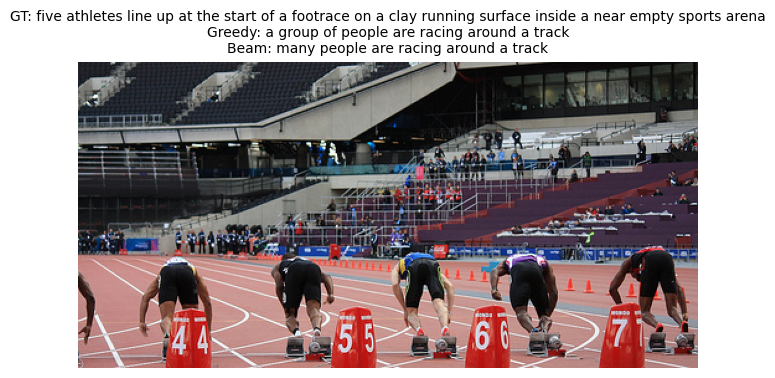

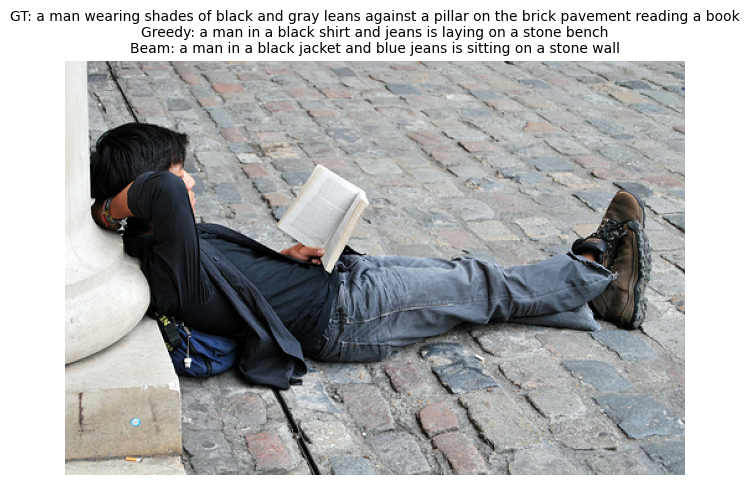

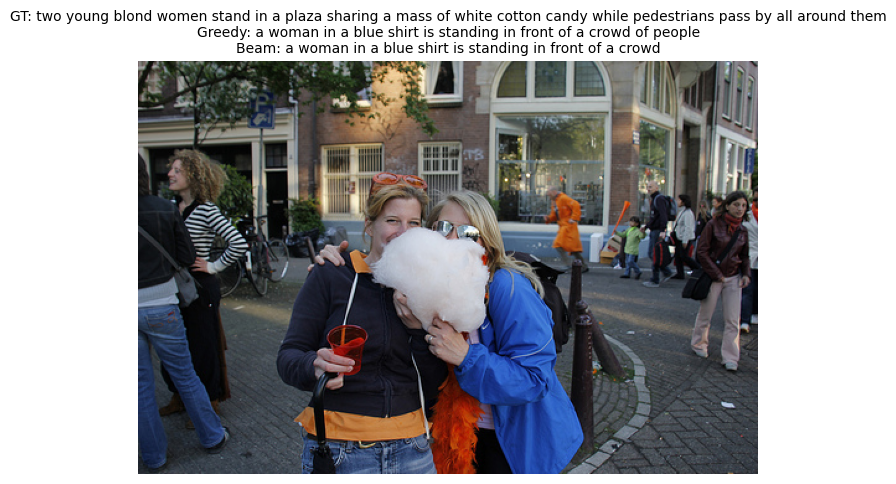

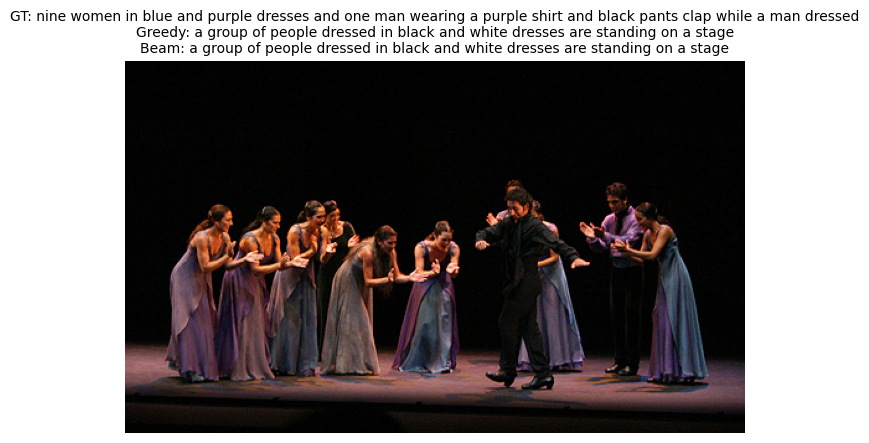

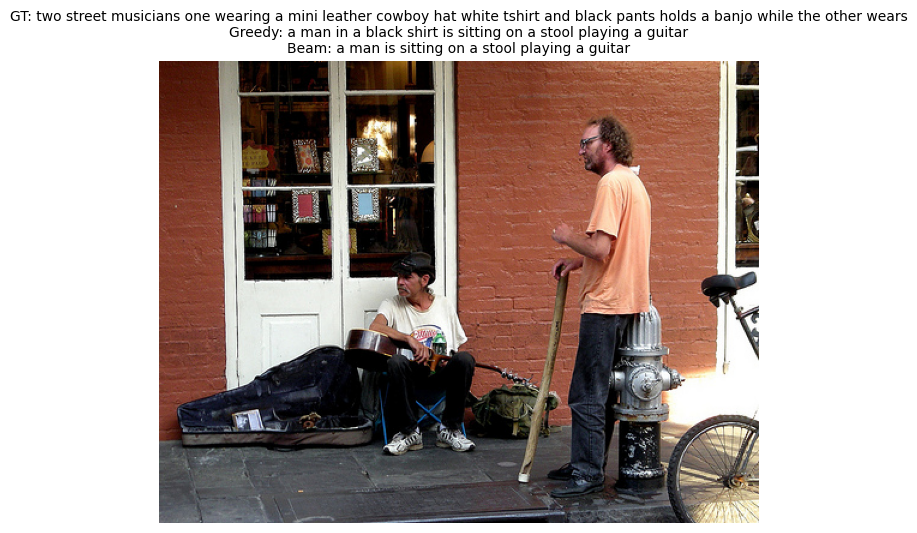

In [32]:
model.load_state_dict(torch.load('model_weights.pth'))
model.eval()

image_dir = find_image_dir()

if IMAGE_DIR:
    print(f" Found images at: {IMAGE_DIR}")
else:
    raise FileNotFoundError("Could not find the Flickr30k image directory. Please ensure the dataset is added to the notebook.")

test_images = random.sample(val_dataset.images, 5)
START_IDX = word2idx['<start>']
END_IDX = word2idx['<end>']
for img_name in test_images:
    img_path = os.path.join(image_dir, img_name)
    img = Image.open(img_path)
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.axis('off')
    features = torch.tensor(image_features[img_name].astype(np.float32)).unsqueeze(0).to(device)
    greedy_caption = greedy_search(model, features, MAX_LENGTH, START_IDX, END_IDX)
    beam_caption = beam_search(model, features, MAX_LENGTH, START_IDX, END_IDX, beam_width=3)
    greedy_words = ' '.join([idx2word[idx] for idx in greedy_caption if idx not in [PAD_IDX, START_IDX, END_IDX]])
    beam_words = ' '.join([idx2word[idx] for idx in beam_caption if idx not in [PAD_IDX, START_IDX, END_IDX]])
    gt_caption = image_to_captions[img_name][0]
    gt_words = ' '.join([idx2word[idx] for idx in gt_caption if idx not in [PAD_IDX, START_IDX, END_IDX]])
    plt.title(f"GT: {gt_words}\nGreedy: {greedy_words}\nBeam: {beam_words}", fontsize=10)
    plt.show()

In [28]:
references = []
hypotheses_greedy = []
hypotheses_beam = []
for img_name in tqdm(val_dataset.images[:500], desc="Evaluating"):
    features = torch.tensor(image_features[img_name].astype(np.float32)).unsqueeze(0).to(device)
    greedy_caption = greedy_search(model, features, MAX_LENGTH, START_IDX, END_IDX)
    beam_caption = beam_search(model, features, MAX_LENGTH, START_IDX, END_IDX, beam_width=3)
    greedy_words = [idx2word[idx] for idx in greedy_caption if idx not in [PAD_IDX, START_IDX, END_IDX]]
    beam_words = [idx2word[idx] for idx in beam_caption if idx not in [PAD_IDX, START_IDX, END_IDX]]
    ref_captions = [[idx2word[idx] for idx in cap if idx not in [PAD_IDX, START_IDX, END_IDX]] for cap in image_to_captions[img_name]]
    references.append(ref_captions)
    hypotheses_greedy.append(greedy_words)
    hypotheses_beam.append(beam_words)
bleu_greedy = corpus_bleu(references, hypotheses_greedy)
bleu_beam = corpus_bleu(references, hypotheses_beam)
print(f"BLEU-4 (Greedy): {bleu_greedy:.4f}")
print(f"BLEU-4 (Beam): {bleu_beam:.4f}")

Evaluating: 100%|██████████| 500/500 [00:44<00:00, 11.11it/s]


BLEU-4 (Greedy): 0.3051
BLEU-4 (Beam): 0.3453


In [29]:
def calculate_token_metrics(references, hypotheses):
    precisions = []
    recalls = []
    f1s = []
    for refs, hyp in zip(references, hypotheses):
        hyp_tokens = set(hyp)
        ref_tokens = set()
        for ref in refs:
            ref_tokens.update(ref)
        if len(hyp_tokens) == 0:
            precisions.append(0)
            recalls.append(0)
            f1s.append(0)
            continue
        tp = len(hyp_tokens & ref_tokens)
        precision = tp / len(hyp_tokens) if len(hyp_tokens) > 0 else 0
        recall = tp / len(ref_tokens) if len(ref_tokens) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)
    return np.mean(precisions), np.mean(recalls), np.mean(f1s)

print("Calculating token-level metrics...")
prec, rec, f1 = calculate_token_metrics(references, hypotheses_beam)
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1-Score: {f1:.4f}")

Calculating token-level metrics...
Precision: 0.7590
Recall: 0.2049
F1-Score: 0.3179
